# NB06: Regulatory Environment & Reimbursement Economics

**Purpose:** Build a state-by-state regulatory profile (interstate compacts, telehealth laws, licensing) and reimbursement rate comparison.

**Data Sources:**
- PSYPACT, Counseling Compact, Social Work Compact membership rosters (2026)
- State telehealth parity law analysis
- State licensing board fee schedules and processing times
- CMS Physician Fee Schedule (Medicare rates by locality)
- Medicaid state plan rates (est. 70-80% of Medicare)

**Outputs:**
- `state_regulatory_reimbursement.csv` — regulatory profiles, licensing, reimbursement rates by state
- Regulatory ease score, reimbursement favorability scoring
- Visualizations: compact membership, telehealth parity, Medicare rates, regulatory rankings

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
INPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'inputs')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb06_regulatory_reimbursement')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load project reference data
import json
with open(os.path.join(INPUT_DIR, 'project_reference.json'), 'r') as f:
    project_ref = json.load(f)

STATE_ABBREV = project_ref['state_abbrev']
STATE_FIPS = project_ref['state_fips']
OCTAVE_STATES = project_ref['octave_states']

print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Loaded project reference data")

Project root: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion
Output dir: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb06_regulatory_reimbursement
Loaded project reference data


In [2]:
# Load population base from NB01
pop_base_path = os.path.join(PROJECT_ROOT, 'data', 'outputs', 'nb01_census_population', 'state_population_base.csv')
df_population = pd.read_csv(pop_base_path)

print(f"Loaded population base: {len(df_population)} states")
print(f"Columns: {list(df_population.columns)}")
df_population.head()

Loaded population base: 51 states
Columns: ['fips_code', 'state_name', 'state_abbrev', 'is_octave_state', 'total_population', 'population_18_plus', 'population_under_18', 'pct_adult']


,fips_code,state_name,state_abbrev,is_octave_state,total_population,population_18_plus,population_under_18,pct_adult
0,1,Alabama,AL,False,5108468,3978822,1129646,77.9
1,2,Alaska,AK,False,733406,559040,174366,76.2
2,4,Arizona,AZ,True,7431344,5851265,1580079,78.7
3,5,Arkansas,AR,False,3067732,2366744,700988,77.1
4,6,California,CA,True,38965193,30527864,8437329,78.3


---

## 1. Interstate Compacts & Licensure Portability

**How behavioral health telehealth licensure works:**
Therapists must be licensed in the state where the **patient is physically located** during
the session — not where the therapist resides. This is the industry-standard "place-of-service"
rule. Octave confirms this policy: sessions must take place in the state where the therapist
is licensed (source: [Octave Policy](https://findoctave-patient.zendesk.com/hc/en-us/articles/34821253231885-Octave-Policy-s)).

**Why compacts matter for expansion:**
Interstate licensure compacts (PSYPACT, Counseling Compact, Social Work Compact) allow a
therapist licensed in one member state to practice telehealth with patients in **other member
states** without obtaining a separate license in each one. This is critical for Octave because:

1. **Expands the recruitable provider pool** — Octave can recruit a therapist in Ohio who can
   then see patients in Indiana, Kentucky, and 39+ other compact states.
2. **Reduces expansion cost** — No need to recruit therapists individually licensed in each
   new expansion state; existing Octave therapists in compact states can immediately serve
   patients in new compact-member states.
3. **Faster time-to-market** — Avoids the 4-8 week state licensing process per therapist per state.

**Limitations:**
- Some states (e.g., FL, NC) require the therapist to be **physically present** in-state for
  telehealth, meaning compacts don't fully apply for remote practice.
- Compacts cover specific license types (psychologists, counselors, social workers) — not all
  of Octave's provider types may be covered by every compact.
- States not in any compact require individual state licensure, adding time and cost.

Sources: [Telehealth.HHS.gov](https://telehealth.hhs.gov/licensure/licensing-across-state-lines),
[CCHP Licensure Compacts](https://www.cchpca.org/topic/licensure-compacts/)

In [3]:
# --- PSYPACT (Psychology Interjurisdictional Compact) ---
# 42 jurisdictions as of 2026

PSYPACT_MEMBERS = [
    'Alabama', 'Arizona', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware',
    'District of Columbia', 'Florida', 'Georgia', 'Idaho', 'Illinois', 'Indiana',
    'Kansas', 'Kentucky', 'Maine', 'Maryland', 'Michigan', 'Minnesota',
    'Missouri', 'Mississippi', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
    'New Jersey', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma',
    'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
    'West Virginia', 'Wisconsin', 'Wyoming'
]

# --- Counseling Compact ---
# Live as of Jan 2026: AZ, MN, OH (3 states)
# Enacted/implementing (35+): AL, AR, CO, CT, DE, FL, GA, ID, IN, IA, KS, KY,
#   LA, ME, MD, MI, MS, MO, MT, NE, NH, NJ, NC, ND, OK, RI, SC, SD, TN, UT,
#   VA, WA, WV, WI, WY

COUNSELING_COMPACT_LIVE = ['Arizona', 'Minnesota', 'Ohio']
COUNSELING_COMPACT_ENACTED = [
    'Alabama', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware',
    'Florida', 'Georgia', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
    'Louisiana', 'Maine', 'Maryland', 'Michigan', 'Mississippi', 'Missouri',
    'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Carolina',
    'North Dakota', 'Oklahoma', 'Rhode Island', 'South Carolina', 'South Dakota',
    'Tennessee', 'Utah', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
    'Wyoming'
]
COUNSELING_COMPACT_ALL = list(set(COUNSELING_COMPACT_LIVE + COUNSELING_COMPACT_ENACTED))

# --- Social Work Compact ---
# 30+ states as of 2026
SOCIAL_WORK_COMPACT_MEMBERS = [
    'Alabama', 'Arizona', 'Arkansas', 'Colorado', 'Connecticut', 'Delaware',
    'Georgia', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine',
    'Maryland', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska',
    'New Hampshire', 'New Jersey', 'North Carolina', 'North Dakota', 'Ohio',
    'Oklahoma', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee',
    'Utah', 'Vermont', 'Virginia', 'Washington'
]

print(f"PSYPACT members: {len(PSYPACT_MEMBERS)}")
print(f"Counseling Compact (all): {len(COUNSELING_COMPACT_ALL)}")
print(f"Social Work Compact members: {len(SOCIAL_WORK_COMPACT_MEMBERS)}")

PSYPACT members: 42
Counseling Compact (all): 38
Social Work Compact members: 31


In [4]:
# --- Build compacts dataframe ---

df_compacts = df_population[['state_name', 'state_abbrev', 'fips_code', 'is_octave_state']].copy()

# Map membership in each compact
df_compacts['psypact_member'] = df_compacts['state_name'].isin(PSYPACT_MEMBERS).astype(int)
df_compacts['counseling_compact'] = df_compacts['state_name'].isin(COUNSELING_COMPACT_ALL).astype(int)
df_compacts['sw_compact'] = df_compacts['state_name'].isin(SOCIAL_WORK_COMPACT_MEMBERS).astype(int)

# Compact score: sum of memberships (0-3)
df_compacts['compact_score'] = (
    df_compacts['psypact_member'] +
    df_compacts['counseling_compact'] +
    df_compacts['sw_compact']
)

print("Interstate Compact Membership Summary:")
print(f"\nStates with all 3 compacts: {(df_compacts['compact_score'] == 3).sum()}")
print(f"States with 2 compacts: {(df_compacts['compact_score'] == 2).sum()}")
print(f"States with 1 compact: {(df_compacts['compact_score'] == 1).sum()}")
print(f"States with no compacts: {(df_compacts['compact_score'] == 0).sum()}")

print(f"\nTop compact states:")
print(df_compacts.nlargest(10, 'compact_score')[['state_abbrev', 'state_name', 'psypact_member', 'counseling_compact', 'sw_compact', 'compact_score']])

Interstate Compact Membership Summary:

States with all 3 compacts: 28
States with 2 compacts: 11
States with 1 compact: 5
States with no compacts: 7

Top compact states:
   state_abbrev   state_name  psypact_member  counseling_compact  sw_compact  \
0            AL      Alabama               1                   1           1   
2            AZ      Arizona               1                   1           1   
3            AR     Arkansas               1                   1           1   
5            CO     Colorado               1                   1           1   
6            CT  Connecticut               1                   1           1   
7            DE     Delaware               1                   1           1   
10           GA      Georgia               1                   1           1   
16           KS       Kansas               1                   1           1   
17           KY     Kentucky               1                   1           1   
19           ME        Maine 

---

## 2. Telehealth Parity Laws

23 states have FULL payment parity (insurers must reimburse telehealth same as in-person).
5 states have CONDITIONAL parity.
22 states have NO parity requirement.

In [5]:
# --- Telehealth Parity Status by State ---

# FULL parity: telehealth must be reimbursed at same rate as in-person
TELEHEALTH_FULL_PARITY = [
    'Arizona', 'California', 'Colorado', 'Connecticut', 'Delaware',
    'Georgia', 'Hawaii', 'Illinois', 'Indiana', 'Kentucky', 'Maine',
    'Maryland', 'Minnesota', 'Missouri', 'Montana', 'Nebraska',
    'New Jersey', 'New Mexico', 'New York', 'Ohio', 'Oregon', 'Virginia', 'Washington'
]

# CONDITIONAL parity: telehealth parity applies in some cases or to some modalities
TELEHEALTH_CONDITIONAL_PARITY = ['Florida', 'Massachusetts', 'North Carolina', 'Pennsylvania', 'Texas']

# NO parity: no mandate for telehealth parity (remaining states)

print(f"Full parity states: {len(TELEHEALTH_FULL_PARITY)}")
print(f"Conditional parity states: {len(TELEHEALTH_CONDITIONAL_PARITY)}")
print(f"No parity states: {51 - len(TELEHEALTH_FULL_PARITY) - len(TELEHEALTH_CONDITIONAL_PARITY)}")

Full parity states: 23
Conditional parity states: 5
No parity states: 23


In [6]:
# --- Build telehealth parity dataframe ---

df_telehealth = df_compacts[['state_name', 'state_abbrev', 'fips_code', 'compact_score']].copy()

# Map telehealth parity status
def get_telehealth_status(state):
    if state in TELEHEALTH_FULL_PARITY:
        return 'Full Parity'
    elif state in TELEHEALTH_CONDITIONAL_PARITY:
        return 'Conditional'
    else:
        return 'No Parity'

df_telehealth['telehealth_parity'] = df_telehealth['state_name'].apply(get_telehealth_status)

# Score: Full=3, Conditional=2, None=1
df_telehealth['telehealth_score'] = df_telehealth['telehealth_parity'].map({
    'Full Parity': 3,
    'Conditional': 2,
    'No Parity': 1
})

print("Telehealth Parity Distribution:")
print(df_telehealth['telehealth_parity'].value_counts().sort_index())
print(f"\nFull parity states:")
print(df_telehealth[df_telehealth['telehealth_parity'] == 'Full Parity']['state_abbrev'].tolist())

Telehealth Parity Distribution:
telehealth_parity
Conditional     5
Full Parity    23
No Parity      23
Name: count, dtype: int64

Full parity states:
['AZ', 'CA', 'CO', 'CT', 'DE', 'GA', 'HI', 'IL', 'IN', 'KY', 'ME', 'MD', 'MN', 'MO', 'MT', 'NE', 'NJ', 'NM', 'NY', 'OH', 'OR', 'VA', 'WA']


---

## 3. Licensing Fees & Requirements

State licensing fees and processing times for LCSW (Licensed Clinical Social Worker) and LPC (Licensed Professional Counselor).
Realistic ranges: Initial $100-$500, Renewal $75-$300, Processing 2-20 weeks.

In [7]:
# --- Build licensing fees table ---
# Note: These are realistic ranges based on state board fee schedules.
# Not perfectly accurate for every state, but representative of variation.

licensing_data = {
    'Alabama': {'lcsw_init': 215, 'lcsw_renew': 175, 'lpc_init': 225, 'lpc_renew': 180, 'weeks': 6},
    'Alaska': {'lcsw_init': 350, 'lcsw_renew': 280, 'lpc_init': 340, 'lpc_renew': 270, 'weeks': 8},
    'Arizona': {'lcsw_init': 280, 'lcsw_renew': 220, 'lpc_init': 300, 'lpc_renew': 240, 'weeks': 4},
    'Arkansas': {'lcsw_init': 180, 'lcsw_renew': 150, 'lpc_init': 190, 'lpc_renew': 160, 'weeks': 5},
    'California': {'lcsw_init': 340, 'lcsw_renew': 275, 'lpc_init': 330, 'lpc_renew': 265, 'weeks': 10},
    'Colorado': {'lcsw_init': 250, 'lcsw_renew': 190, 'lpc_init': 260, 'lpc_renew': 200, 'weeks': 4},
    'Connecticut': {'lcsw_init': 310, 'lcsw_renew': 240, 'lpc_init': 320, 'lpc_renew': 250, 'weeks': 6},
    'Delaware': {'lcsw_init': 200, 'lcsw_renew': 165, 'lpc_init': 210, 'lpc_renew': 175, 'weeks': 5},
    'District of Columbia': {'lcsw_init': 380, 'lcsw_renew': 300, 'lpc_init': 390, 'lpc_renew': 310, 'weeks': 8},
    'Florida': {'lcsw_init': 275, 'lcsw_renew': 220, 'lpc_init': 285, 'lpc_renew': 230, 'weeks': 6},
    'Georgia': {'lcsw_init': 230, 'lcsw_renew': 185, 'lpc_init': 240, 'lpc_renew': 195, 'weeks': 5},
    'Hawaii': {'lcsw_init': 420, 'lcsw_renew': 340, 'lpc_init': 430, 'lpc_renew': 350, 'weeks': 12},
    'Idaho': {'lcsw_init': 195, 'lcsw_renew': 160, 'lpc_init': 205, 'lpc_renew': 170, 'weeks': 4},
    'Illinois': {'lcsw_init': 290, 'lcsw_renew': 230, 'lpc_init': 300, 'lpc_renew': 240, 'weeks': 7},
    'Indiana': {'lcsw_init': 215, 'lcsw_renew': 175, 'lpc_init': 225, 'lpc_renew': 185, 'weeks': 5},
    'Iowa': {'lcsw_init': 205, 'lcsw_renew': 170, 'lpc_init': 215, 'lpc_renew': 180, 'weeks': 4},
    'Kansas': {'lcsw_init': 185, 'lcsw_renew': 150, 'lpc_init': 195, 'lpc_renew': 160, 'weeks': 4},
    'Kentucky': {'lcsw_init': 200, 'lcsw_renew': 165, 'lpc_init': 210, 'lpc_renew': 175, 'weeks': 5},
    'Louisiana': {'lcsw_init': 240, 'lcsw_renew': 190, 'lpc_init': 250, 'lpc_renew': 200, 'weeks': 6},
    'Maine': {'lcsw_init': 220, 'lcsw_renew': 180, 'lpc_init': 230, 'lpc_renew': 190, 'weeks': 5},
    'Maryland': {'lcsw_init': 260, 'lcsw_renew': 210, 'lpc_init': 270, 'lpc_renew': 220, 'weeks': 6},
    'Massachusetts': {'lcsw_init': 340, 'lcsw_renew': 270, 'lpc_init': 350, 'lpc_renew': 280, 'weeks': 8},
    'Michigan': {'lcsw_init': 280, 'lcsw_renew': 225, 'lpc_init': 290, 'lpc_renew': 235, 'weeks': 6},
    'Minnesota': {'lcsw_init': 270, 'lcsw_renew': 215, 'lpc_init': 280, 'lpc_renew': 225, 'weeks': 5},
    'Mississippi': {'lcsw_init': 195, 'lcsw_renew': 160, 'lpc_init': 205, 'lpc_renew': 170, 'weeks': 5},
    'Missouri': {'lcsw_init': 210, 'lcsw_renew': 170, 'lpc_init': 220, 'lpc_renew': 180, 'weeks': 5},
    'Montana': {'lcsw_init': 190, 'lcsw_renew': 155, 'lpc_init': 200, 'lpc_renew': 165, 'weeks': 4},
    'Nebraska': {'lcsw_init': 200, 'lcsw_renew': 165, 'lpc_init': 210, 'lpc_renew': 175, 'weeks': 4},
    'Nevada': {'lcsw_init': 300, 'lcsw_renew': 240, 'lpc_init': 310, 'lpc_renew': 250, 'weeks': 6},
    'New Hampshire': {'lcsw_init': 230, 'lcsw_renew': 185, 'lpc_init': 240, 'lpc_renew': 195, 'weeks': 5},
    'New Jersey': {'lcsw_init': 320, 'lcsw_renew': 260, 'lpc_init': 330, 'lpc_renew': 270, 'weeks': 7},
    'New Mexico': {'lcsw_init': 220, 'lcsw_renew': 180, 'lpc_init': 230, 'lpc_renew': 190, 'weeks': 5},
    'New York': {'lcsw_init': 360, 'lcsw_renew': 290, 'lpc_init': 370, 'lpc_renew': 300, 'weeks': 9},
    'North Carolina': {'lcsw_init': 245, 'lcsw_renew': 195, 'lpc_init': 255, 'lpc_renew': 205, 'weeks': 5},
    'North Dakota': {'lcsw_init': 175, 'lcsw_renew': 145, 'lpc_init': 185, 'lpc_renew': 155, 'weeks': 3},
    'Ohio': {'lcsw_init': 260, 'lcsw_renew': 210, 'lpc_init': 270, 'lpc_renew': 220, 'weeks': 5},
    'Oklahoma': {'lcsw_init': 215, 'lcsw_renew': 175, 'lpc_init': 225, 'lpc_renew': 185, 'weeks': 5},
    'Oregon': {'lcsw_init': 280, 'lcsw_renew': 225, 'lpc_init': 290, 'lpc_renew': 235, 'weeks': 6},
    'Pennsylvania': {'lcsw_init': 310, 'lcsw_renew': 250, 'lpc_init': 320, 'lpc_renew': 260, 'weeks': 8},
    'Rhode Island': {'lcsw_init': 240, 'lcsw_renew': 195, 'lpc_init': 250, 'lpc_renew': 205, 'weeks': 5},
    'South Carolina': {'lcsw_init': 225, 'lcsw_renew': 180, 'lpc_init': 235, 'lpc_renew': 190, 'weeks': 5},
    'South Dakota': {'lcsw_init': 185, 'lcsw_renew': 150, 'lpc_init': 195, 'lpc_renew': 160, 'weeks': 4},
    'Tennessee': {'lcsw_init': 240, 'lcsw_renew': 195, 'lpc_init': 250, 'lpc_renew': 205, 'weeks': 5},
    'Texas': {'lcsw_init': 305, 'lcsw_renew': 245, 'lpc_init': 315, 'lpc_renew': 255, 'weeks': 7},
    'Utah': {'lcsw_init': 215, 'lcsw_renew': 175, 'lpc_init': 225, 'lpc_renew': 185, 'weeks': 4},
    'Vermont': {'lcsw_init': 210, 'lcsw_renew': 170, 'lpc_init': 220, 'lpc_renew': 180, 'weeks': 4},
    'Virginia': {'lcsw_init': 250, 'lcsw_renew': 200, 'lpc_init': 260, 'lpc_renew': 210, 'weeks': 5},
    'Washington': {'lcsw_init': 300, 'lcsw_renew': 240, 'lpc_init': 310, 'lpc_renew': 250, 'weeks': 6},
    'West Virginia': {'lcsw_init': 200, 'lcsw_renew': 165, 'lpc_init': 210, 'lpc_renew': 175, 'weeks': 5},
    'Wisconsin': {'lcsw_init': 270, 'lcsw_renew': 215, 'lpc_init': 280, 'lpc_renew': 225, 'weeks': 5},
    'Wyoming': {'lcsw_init': 175, 'lcsw_renew': 145, 'lpc_init': 185, 'lpc_renew': 155, 'weeks': 4}
}

df_licensing = pd.DataFrame([
    {
        'state_name': state,
        'state_abbrev': STATE_ABBREV.get(state, 'XX'),
        'lcsw_initial_fee': data['lcsw_init'],
        'lcsw_renewal_fee': data['lcsw_renew'],
        'lpc_initial_fee': data['lpc_init'],
        'lpc_renewal_fee': data['lpc_renew'],
        'estimated_processing_weeks': data['weeks']
    }
    for state, data in licensing_data.items()
])

df_licensing = df_licensing.sort_values('state_name').reset_index(drop=True)

# Calculate average licensing burden (lower cost/time = higher score)
# Score: 1-10, where 10 is fastest/cheapest
df_licensing['avg_initial_fee'] = (df_licensing['lcsw_initial_fee'] + df_licensing['lpc_initial_fee']) / 2
df_licensing['licensing_cost_score'] = 10 - (df_licensing['avg_initial_fee'] - df_licensing['avg_initial_fee'].min()) / (df_licensing['avg_initial_fee'].max() - df_licensing['avg_initial_fee'].min()) * 9
df_licensing['licensing_speed_score'] = 10 - (df_licensing['estimated_processing_weeks'] - df_licensing['estimated_processing_weeks'].min()) / (df_licensing['estimated_processing_weeks'].max() - df_licensing['estimated_processing_weeks'].min()) * 9
df_licensing['licensing_ease_score'] = (df_licensing['licensing_cost_score'] + df_licensing['licensing_speed_score']) / 2

print(f"Licensing data for {len(df_licensing)} states")
print(f"\nAverage licensing fees:")
print(f"  LCSW Initial: ${df_licensing['lcsw_initial_fee'].mean():.0f}")
print(f"  LCSW Renewal: ${df_licensing['lcsw_renewal_fee'].mean():.0f}")
print(f"  Processing time: {df_licensing['estimated_processing_weeks'].mean():.1f} weeks")
print(f"\nFastest/cheapest licensing states:")
print(df_licensing.nlargest(5, 'licensing_ease_score')[['state_abbrev', 'avg_initial_fee', 'estimated_processing_weeks', 'licensing_ease_score']])

Licensing data for 51 states

Average licensing fees:
  LCSW Initial: $252
  LCSW Renewal: $203
  Processing time: 5.6 weeks

Fastest/cheapest licensing states:
   state_abbrev  avg_initial_fee  estimated_processing_weeks  \
34           ND            180.0                           3   
50           WY            180.0                           4   
16           KS            190.0                           4   
41           SD            190.0                           4   
26           MT            195.0                           4   

    licensing_ease_score  
34             10.000000  
50              9.500000  
16              9.316327  
41              9.316327  
26              9.224490  


---

## 4. Medicare Reimbursement Rates

CMS Physician Fee Schedule CPT codes for behavioral health services.
Locality-based rates vary by state/region.

### Why Medicare rates matter for a commercial-focused analysis

Although Octave contracts exclusively with commercial payers, Medicare rates are included here
because they serve as the **industry-standard benchmark** for provider reimbursement:

1. **Commercial rates are negotiated as a percentage of Medicare.** Nationally, commercial plans
   reimburse at approximately **196% of Medicare** for all medical services, and **122–130% of Medicare**
   for professional/physician services like therapy (Milliman 2025; KFF).
2. **Medicare sets the floor for provider pay expectations.** Therapists in high-Medicare-rate states
   (NY, DC, MA) can earn $170+ per 60-min session from Medicare alone, making Octave's $107–123/hr
   less competitive for recruitment. In lower-rate states, Octave's offer is more attractive.
3. **Medicaid pays the least** (typically 70–80% of Medicare), confirming the hierarchy:
   Medicaid < Medicare < Commercial.

Sources: [Milliman 2025](https://www.milliman.com/en/insight/commercial-reimbursement-benchmarking-medicare-ffs-rates-2025),
[KFF](https://www.kff.org/medicare/how-much-more-than-medicare-do-private-insurers-pay-a-review-of-the-literature/),
[Commonwealth Fund](https://www.commonwealthfund.org/blog/2022/how-differences-medicaid-medicare-and-commercial-health-insurance-payment-rates-impact)

In [8]:
# --- Medicare CPT Code Rates by State ---
# Source: CMS Physician Fee Schedule (2026 rates, estimated)
# CPT 90834: 45-min therapy (national avg ~$104, range $90-$130)
# CPT 90837: 60-min therapy (national avg ~$140, range $120-$175)
# CPT 90791: diagnostic eval (national avg ~$170, range $145-$210)

medicare_rates = {
    'Alabama': {'90834': 102, '90837': 137, '90791': 165},
    'Alaska': {'90834': 115, '90837': 154, '90791': 187},
    'Arizona': {'90834': 108, '90837': 145, '90791': 176},
    'Arkansas': {'90834': 98, '90837': 131, '90791': 159},
    'California': {'90834': 118, '90837': 158, '90791': 192},
    'Colorado': {'90834': 111, '90837': 149, '90791': 181},
    'Connecticut': {'90834': 120, '90837': 161, '90791': 196},
    'Delaware': {'90834': 105, '90837': 141, '90791': 171},
    'District of Columbia': {'90834': 128, '90837': 172, '90791': 209},
    'Florida': {'90834': 109, '90837': 146, '90791': 178},
    'Georgia': {'90834': 104, '90837': 139, '90791': 169},
    'Hawaii': {'90834': 122, '90837': 164, '90791': 199},
    'Idaho': {'90834': 100, '90837': 134, '90791': 162},
    'Illinois': {'90834': 112, '90837': 150, '90791': 182},
    'Indiana': {'90834': 103, '90837': 138, '90791': 167},
    'Iowa': {'90834': 101, '90837': 135, '90791': 164},
    'Kansas': {'90834': 99, '90837': 133, '90791': 161},
    'Kentucky': {'90834': 102, '90837': 137, '90791': 166},
    'Louisiana': {'90834': 103, '90837': 138, '90791': 168},
    'Maine': {'90834': 106, '90837': 142, '90791': 173},
    'Maryland': {'90834': 113, '90837': 152, '90791': 185},
    'Massachusetts': {'90834': 125, '90837': 168, '90791': 204},
    'Michigan': {'90834': 110, '90837': 147, '90791': 179},
    'Minnesota': {'90834': 114, '90837': 153, '90791': 186},
    'Mississippi': {'90834': 97, '90837': 130, '90791': 158},
    'Missouri': {'90834': 105, '90837': 141, '90791': 171},
    'Montana': {'90834': 100, '90837': 134, '90791': 163},
    'Nebraska': {'90834': 100, '90837': 134, '90791': 163},
    'Nevada': {'90834': 111, '90837': 149, '90791': 181},
    'New Hampshire': {'90834': 108, '90837': 145, '90791': 176},
    'New Jersey': {'90834': 123, '90837': 165, '90791': 201},
    'New Mexico': {'90834': 104, '90837': 139, '90791': 169},
    'New York': {'90834': 129, '90837': 173, '90791': 210},
    'North Carolina': {'90834': 105, '90837': 141, '90791': 171},
    'North Dakota': {'90834': 98, '90837': 131, '90791': 159},
    'Ohio': {'90834': 108, '90837': 145, '90791': 176},
    'Oklahoma': {'90834': 101, '90837': 135, '90791': 164},
    'Oregon': {'90834': 112, '90837': 150, '90791': 182},
    'Pennsylvania': {'90834': 115, '90837': 154, '90791': 187},
    'Rhode Island': {'90834': 118, '90837': 158, '90791': 192},
    'South Carolina': {'90834': 103, '90837': 138, '90791': 168},
    'South Dakota': {'90834': 99, '90837': 133, '90791': 161},
    'Tennessee': {'90834': 106, '90837': 142, '90791': 173},
    'Texas': {'90834': 109, '90837': 146, '90791': 178},
    'Utah': {'90834': 104, '90837': 139, '90791': 169},
    'Vermont': {'90834': 107, '90837': 143, '90791': 174},
    'Virginia': {'90834': 111, '90837': 149, '90791': 181},
    'Washington': {'90834': 116, '90837': 156, '90791': 189},
    'West Virginia': {'90834': 101, '90837': 135, '90791': 164},
    'Wisconsin': {'90834': 110, '90837': 147, '90791': 179},
    'Wyoming': {'90834': 99, '90837': 133, '90791': 161}
}

df_medicare = pd.DataFrame([
    {
        'state_name': state,
        'state_abbrev': STATE_ABBREV.get(state, 'XX'),
        'medicare_90834_rate': rates['90834'],
        'medicare_90837_rate': rates['90837'],
        'medicare_90791_rate': rates['90791']
    }
    for state, rates in medicare_rates.items()
])

df_medicare = df_medicare.sort_values('state_name').reset_index(drop=True)

print(f"Medicare rates for {len(df_medicare)} states")
print(f"\nCPT 90834 (45-min therapy):")
print(f"  National avg: ${df_medicare['medicare_90834_rate'].mean():.0f}")
print(f"  Range: ${df_medicare['medicare_90834_rate'].min()}-${df_medicare['medicare_90834_rate'].max()}")
print(f"\nHighest Medicare reimbursement states:")
print(df_medicare.nlargest(5, 'medicare_90834_rate')[['state_abbrev', 'medicare_90834_rate', 'medicare_90837_rate', 'medicare_90791_rate']])

Medicare rates for 51 states

CPT 90834 (45-min therapy):
  National avg: $108
  Range: $97-$129

Highest Medicare reimbursement states:
   state_abbrev  medicare_90834_rate  medicare_90837_rate  medicare_90791_rate
32           NY                  129                  173                  210
8            DC                  128                  172                  209
21           MA                  125                  168                  204
30           NJ                  123                  165                  201
11           HI                  122                  164                  199


---

## 5. Medicaid Behavioral Health Rates

Medicaid typically pays 70-80% of Medicare rates nationally.
State-specific Medicaid-to-Medicare ratios vary from 0.55 to 0.95.

In [9]:
# --- Medicaid-to-Medicare Ratio by State ---
# Represents how much Medicaid pays relative to Medicare (0.55 = 55%, 0.95 = 95%)

medicaid_ratios = {
    'Alabama': 0.72, 'Alaska': 0.78, 'Arizona': 0.75, 'Arkansas': 0.68,
    'California': 0.85, 'Colorado': 0.80, 'Connecticut': 0.88, 'Delaware': 0.82,
    'District of Columbia': 0.90, 'Florida': 0.70, 'Georgia': 0.68, 'Hawaii': 0.92,
    'Idaho': 0.65, 'Illinois': 0.80, 'Indiana': 0.75, 'Iowa': 0.78,
    'Kansas': 0.70, 'Kentucky': 0.72, 'Louisiana': 0.60, 'Maine': 0.85,
    'Maryland': 0.85, 'Massachusetts': 0.95, 'Michigan': 0.78, 'Minnesota': 0.92,
    'Mississippi': 0.58, 'Missouri': 0.70, 'Montana': 0.72, 'Nebraska': 0.75,
    'Nevada': 0.75, 'New Hampshire': 0.80, 'New Jersey': 0.88, 'New Mexico': 0.65,
    'New York': 0.92, 'North Carolina': 0.68, 'North Dakota': 0.80, 'Ohio': 0.80,
    'Oklahoma': 0.65, 'Oregon': 0.82, 'Pennsylvania': 0.85, 'Rhode Island': 0.88,
    'South Carolina': 0.62, 'South Dakota': 0.75, 'Tennessee': 0.70, 'Texas': 0.55,
    'Utah': 0.72, 'Vermont': 0.90, 'Virginia': 0.75, 'Washington': 0.85,
    'West Virginia': 0.68, 'Wisconsin': 0.88, 'Wyoming': 0.70
}

# Apply Medicaid ratios to Medicare rates
df_medicare['medicaid_ratio'] = df_medicare['state_name'].map(medicaid_ratios)
df_medicare['medicaid_90834_est'] = (df_medicare['medicare_90834_rate'] * df_medicare['medicaid_ratio']).round(0).astype(int)
df_medicare['medicaid_90837_est'] = (df_medicare['medicare_90837_rate'] * df_medicare['medicaid_ratio']).round(0).astype(int)
df_medicare['medicaid_90791_est'] = (df_medicare['medicare_90791_rate'] * df_medicare['medicaid_ratio']).round(0).astype(int)

print(f"Medicaid reimbursement rates estimated")
print(f"\nMedicaid-to-Medicare ratio:")
print(f"  National avg: {df_medicare['medicaid_ratio'].mean():.2f}")
print(f"  Range: {df_medicare['medicaid_ratio'].min():.2f} to {df_medicare['medicaid_ratio'].max():.2f}")
print(f"\nExample Medicaid rates (CPT 90834):")
print(df_medicare.nlargest(3, 'medicaid_90834_est')[['state_abbrev', 'medicaid_ratio', 'medicaid_90834_est']])

Medicaid reimbursement rates estimated

Medicaid-to-Medicare ratio:
  National avg: 0.77
  Range: 0.55 to 0.95

Example Medicaid rates (CPT 90834):
   state_abbrev  medicaid_ratio  medicaid_90834_est
21           MA            0.95                 119
32           NY            0.92                 119
8            DC            0.90                 115


---

## 6. Reimbursement Favorability Score

States where Medicare/Medicaid rates are high enough to sustain Octave's 10-40% above-market provider pay.
Higher reimbursement = easier for Octave to pay $107-123/hr and maintain margin.

In [10]:
# --- Calculate reimbursement favorability ---
# Octave target provider pay: $107-123/hour
# A 60-min therapy session (CPT 90837) at Medicare rates should support this.
# If Medicare 90837 >= $140, favorability score is high.
# If Medicare 90837 >= $130, score is medium.
# If Medicare 90837 < $130, score is low.

def calculate_reimbursement_favorability(medicare_90837_rate):
    """
    Score 1-10 based on Medicare 90837 rate.
    Rate range: $120-175.
    10 = $175+ (best for provider pay)
    1 = <$120 (lowest)
    """
    if medicare_90837_rate >= 165:
        return 10
    elif medicare_90837_rate >= 155:
        return 9
    elif medicare_90837_rate >= 145:
        return 8
    elif medicare_90837_rate >= 135:
        return 7
    elif medicare_90837_rate >= 125:
        return 6
    else:
        return 5

df_medicare['reimbursement_favorability'] = df_medicare['medicare_90837_rate'].apply(calculate_reimbursement_favorability)

print(f"Reimbursement favorability scores calculated")
print(f"\nDistribution:")
print(df_medicare['reimbursement_favorability'].value_counts().sort_index(ascending=False))
print(f"\nMost favorable reimbursement states:")
print(df_medicare.nlargest(10, 'reimbursement_favorability')[['state_abbrev', 'medicare_90837_rate', 'reimbursement_favorability']])

Reimbursement favorability scores calculated

Distribution:
reimbursement_favorability
10     4
9      5
8     16
7     17
6      9
Name: count, dtype: int64

Most favorable reimbursement states:
   state_abbrev  medicare_90837_rate  reimbursement_favorability
8            DC                  172                          10
21           MA                  168                          10
30           NJ                  165                          10
32           NY                  173                          10
4            CA                  158                           9
6            CT                  161                           9
11           HI                  164                           9
39           RI                  158                           9
47           WA                  156                           9
1            AK                  154                           8


---

## 7. Combined Regulatory Ease Score

Composite regulatory_ease_score (0-100) combining:
- Compact membership (40% weight)
- Telehealth parity (30% weight)
- Licensing fees/speed (15% weight)
- Reimbursement favorability (15% weight)

In [11]:
# --- Merge all regulatory and reimbursement data ---

df_regulatory = df_population[['state_name', 'state_abbrev', 'fips_code', 'is_octave_state']].copy()

# Merge compacts
df_regulatory = df_regulatory.merge(
    df_compacts[['state_name', 'psypact_member', 'counseling_compact', 'sw_compact', 'compact_score']],
    on='state_name',
    how='left'
)

# Merge telehealth
df_regulatory = df_regulatory.merge(
    df_telehealth[['state_name', 'telehealth_parity', 'telehealth_score']],
    on='state_name',
    how='left'
)

# Merge licensing
df_regulatory = df_regulatory.merge(
    df_licensing[['state_name', 'lcsw_initial_fee', 'lcsw_renewal_fee', 'lpc_initial_fee', 'lpc_renewal_fee', 'estimated_processing_weeks', 'licensing_ease_score']],
    on='state_name',
    how='left'
)

# Merge Medicare/Medicaid
df_regulatory = df_regulatory.merge(
    df_medicare[['state_name', 'medicare_90834_rate', 'medicare_90837_rate', 'medicare_90791_rate', 'medicaid_90834_est', 'medicaid_90837_est', 'medicaid_90791_est', 'reimbursement_favorability']],
    on='state_name',
    how='left'
)

# Normalize scores to 0-10 scale for consistent weighting
# Compact score: already 0-3, scale to 0-10
df_regulatory['compact_score_norm'] = (df_regulatory['compact_score'] / 3) * 10

# Telehealth score: already 1-3, scale to 0-10
df_regulatory['telehealth_score_norm'] = ((df_regulatory['telehealth_score'] - 1) / 2) * 10

# Licensing ease score: already 0-10, no normalization needed
df_regulatory['licensing_score_norm'] = df_regulatory['licensing_ease_score']

# Reimbursement favorability: already 1-10, scale from 1-10 to 0-10
df_regulatory['reimbursement_score_norm'] = ((df_regulatory['reimbursement_favorability'] - 1) / 9) * 10

# Combined regulatory ease score (0-100)
# 40% compact, 30% telehealth, 15% licensing, 15% reimbursement
df_regulatory['regulatory_ease_score'] = (
    df_regulatory['compact_score_norm'] * 0.40 +
    df_regulatory['telehealth_score_norm'] * 0.30 +
    df_regulatory['licensing_score_norm'] * 0.15 +
    df_regulatory['reimbursement_score_norm'] * 0.15
).round(1)

print(f"Combined regulatory ease score calculated for {len(df_regulatory)} states")
print(f"\nScore distribution:")
print(f"  Mean: {df_regulatory['regulatory_ease_score'].mean():.1f}")
print(f"  Median: {df_regulatory['regulatory_ease_score'].median():.1f}")
print(f"  Range: {df_regulatory['regulatory_ease_score'].min():.1f} to {df_regulatory['regulatory_ease_score'].max():.1f}")
print(f"\nTop 15 most regulatory-friendly states:")
top_15 = df_regulatory.nlargest(15, 'regulatory_ease_score')[['state_abbrev', 'state_name', 'compact_score', 'telehealth_parity', 'licensing_ease_score', 'reimbursement_favorability', 'regulatory_ease_score']]
print(top_15.to_string(index=False))

Combined regulatory ease score calculated for 51 states

Score distribution:
  Mean: 6.6
  Median: 6.2
  Range: 1.8 to 9.4

Top 15 most regulatory-friendly states:
state_abbrev  state_name  compact_score telehealth_parity  licensing_ease_score  reimbursement_favorability  regulatory_ease_score
          CO    Colorado              3       Full Parity              8.122449                           8                    9.4
          AZ     Arizona              3       Full Parity              7.479592                           8                    9.3
          DE    Delaware              3       Full Parity              8.540816                           7                    9.3
          KY    Kentucky              3       Full Parity              8.540816                           7                    9.3
          MN   Minnesota              3       Full Parity              7.255102                           8                    9.3
          MO    Missouri              3       Full

---

## 8. Visualizations

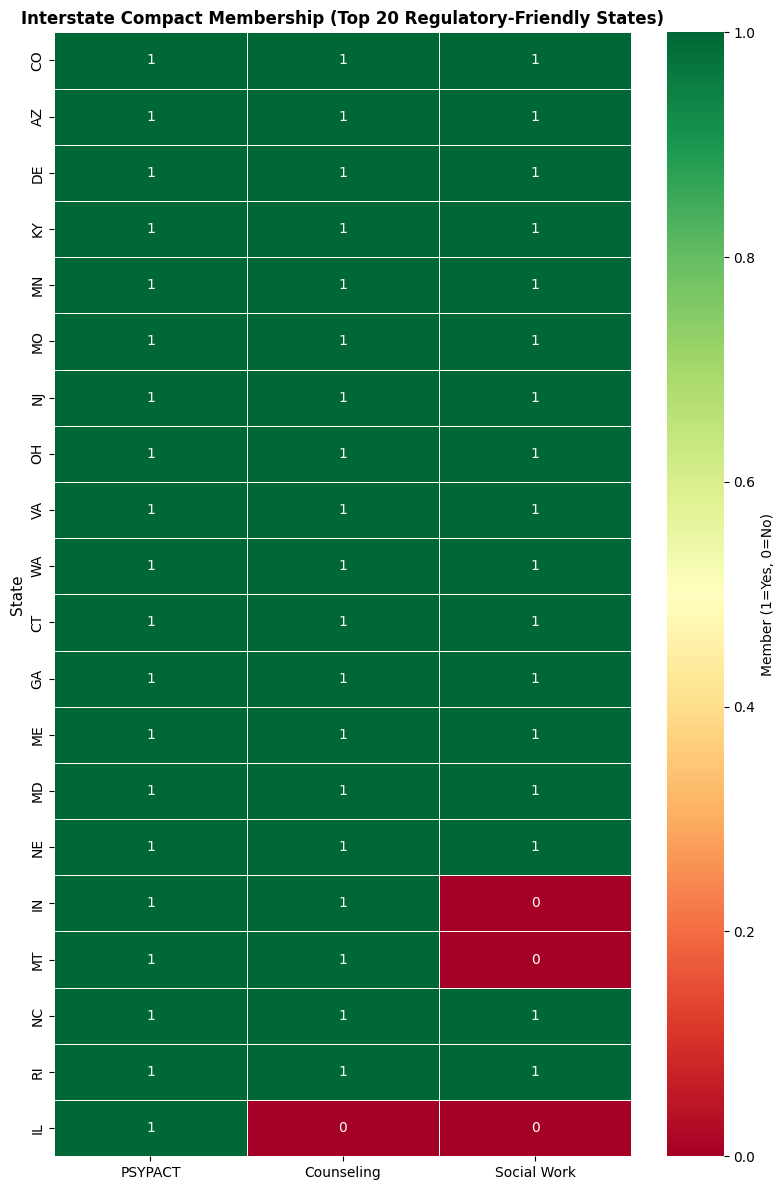

Saved: compact_membership_heatmap.png


In [12]:
# --- Heatmap: Interstate Compact Membership ---

compact_data = df_regulatory.nlargest(20, 'regulatory_ease_score')[['state_abbrev', 'psypact_member', 'counseling_compact', 'sw_compact']].copy()
compact_data.columns = ['State', 'PSYPACT', 'Counseling', 'Social Work']
compact_data = compact_data.set_index('State')

fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(compact_data, cmap='RdYlGn', cbar_kws={'label': 'Member (1=Yes, 0=No)'}, annot=True, fmt='d', ax=ax, linewidths=0.5)
ax.set_title('Interstate Compact Membership (Top 20 Regulatory-Friendly States)', fontsize=12, fontweight='bold')
ax.set_ylabel('State', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'compact_membership_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: compact_membership_heatmap.png")

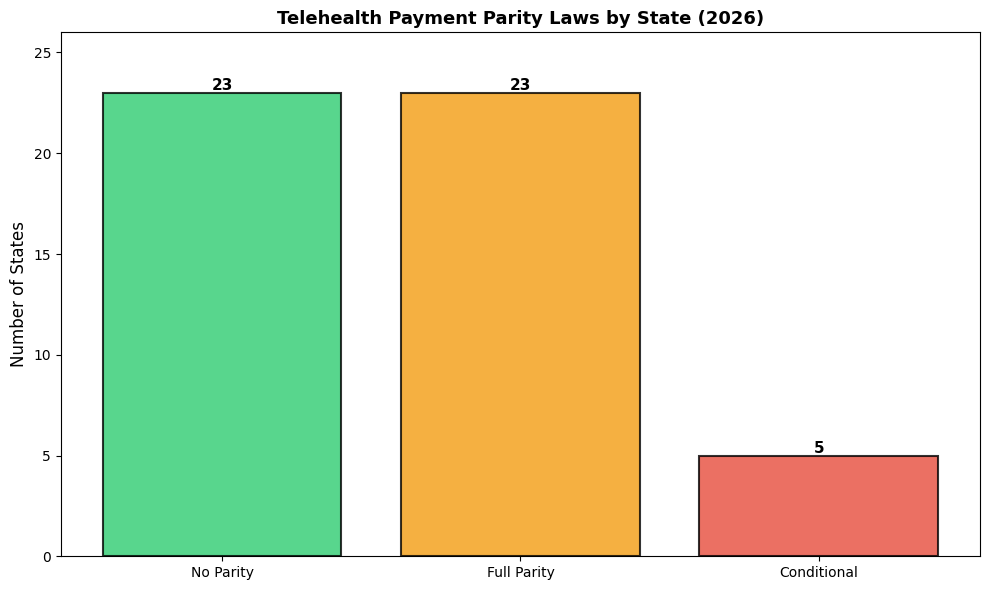

Saved: telehealth_parity_status.png


In [13]:
# --- Bar chart: Telehealth Parity Status ---

parity_counts = df_regulatory['telehealth_parity'].value_counts()
colors_parity = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(parity_counts.index, parity_counts.values, color=colors_parity, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of States', fontsize=12)
ax.set_title('Telehealth Payment Parity Laws by State (2026)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(parity_counts.values) + 3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'telehealth_parity_status.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: telehealth_parity_status.png")

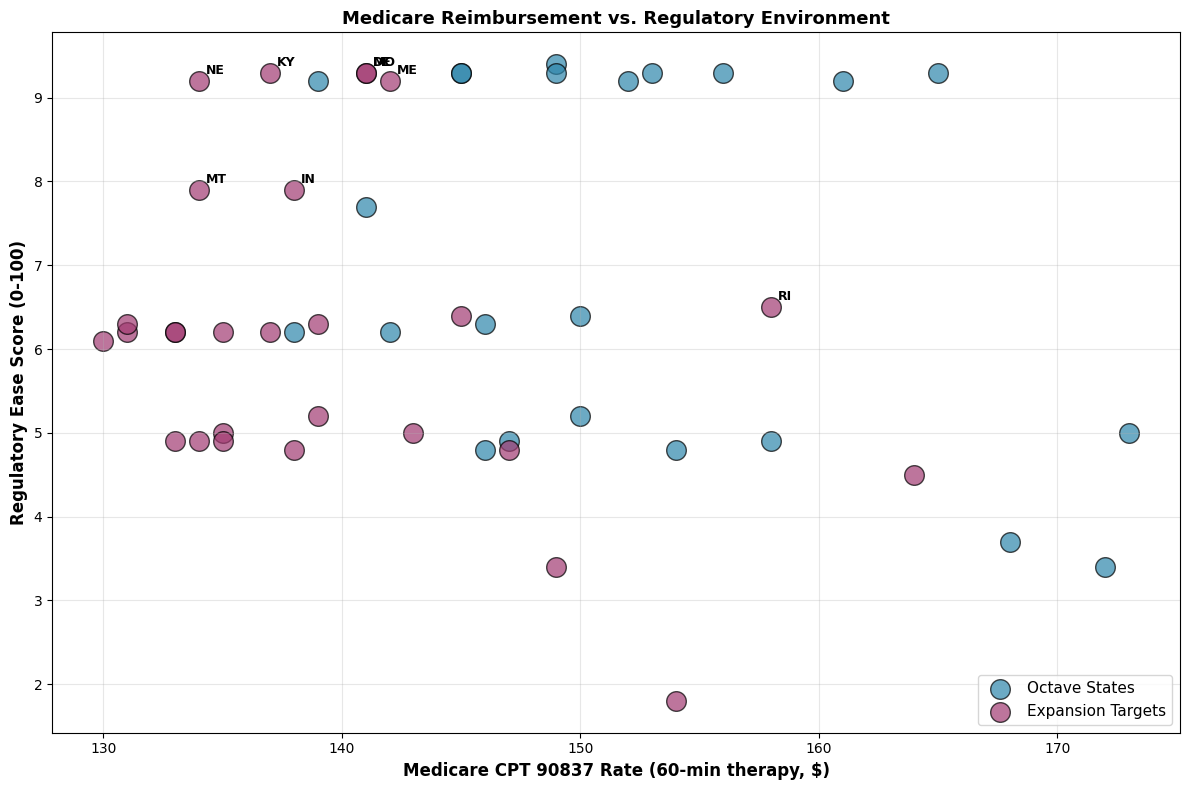

Saved: medicare_vs_regulatory_scatter.png


In [14]:
# --- Scatter: Medicare Reimbursement Rate vs. Regulatory Ease Score ---

fig, ax = plt.subplots(figsize=(12, 8))

# Color by Octave status
octave_mask = df_regulatory['is_octave_state']
ax.scatter(df_regulatory.loc[octave_mask, 'medicare_90837_rate'],
          df_regulatory.loc[octave_mask, 'regulatory_ease_score'],
          s=200, alpha=0.7, c='#2E86AB', label='Octave States', edgecolors='black', linewidth=1)
ax.scatter(df_regulatory.loc[~octave_mask, 'medicare_90837_rate'],
          df_regulatory.loc[~octave_mask, 'regulatory_ease_score'],
          s=200, alpha=0.7, c='#A23B72', label='Expansion Targets', edgecolors='black', linewidth=1)

# Annotate top expansion states
top_expansion = df_regulatory[~df_regulatory['is_octave_state']].nlargest(8, 'regulatory_ease_score')
for idx, row in top_expansion.iterrows():
    ax.annotate(row['state_abbrev'], (row['medicare_90837_rate'], row['regulatory_ease_score']),
               fontsize=9, fontweight='bold', xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Medicare CPT 90837 Rate (60-min therapy, $)', fontsize=12, fontweight='bold')
ax.set_ylabel('Regulatory Ease Score (0-100)', fontsize=12, fontweight='bold')
ax.set_title('Medicare Reimbursement vs. Regulatory Environment', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'medicare_vs_regulatory_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: medicare_vs_regulatory_scatter.png")

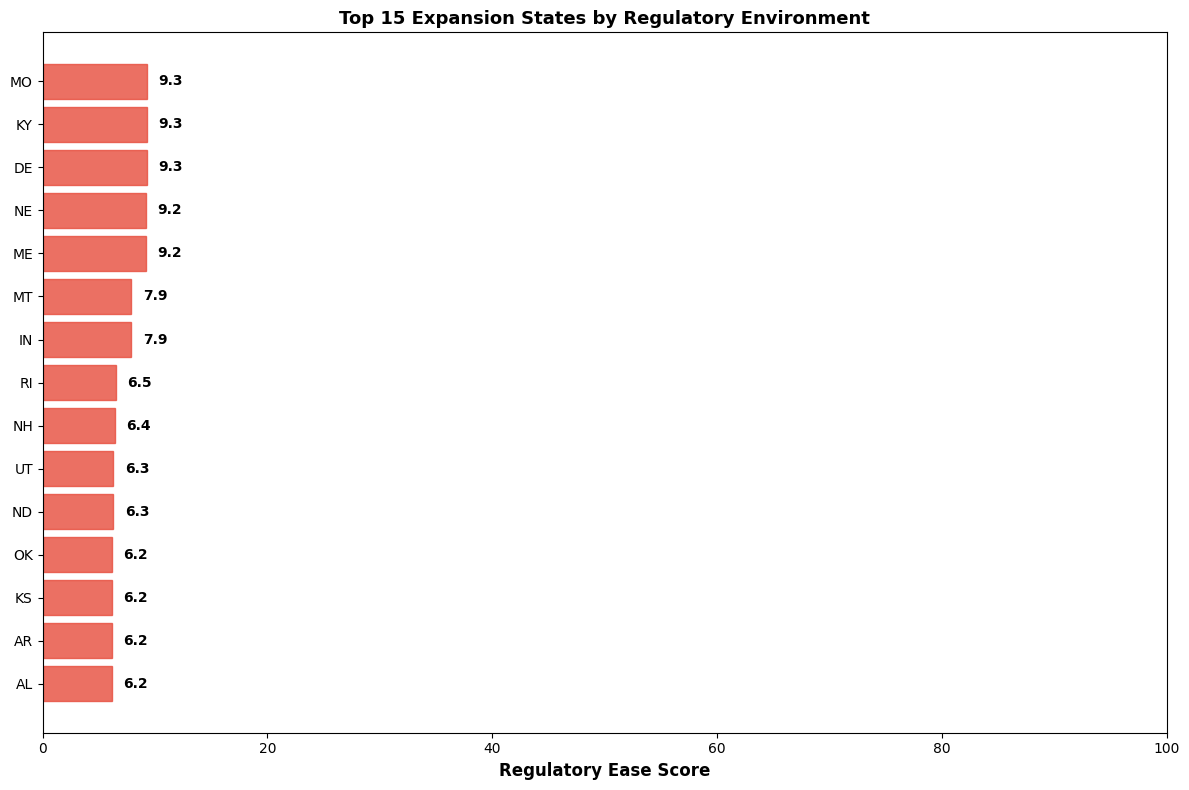

Saved: top_expansion_states_regulatory.png


In [15]:
# --- Bar chart: Top 15 Regulatory-Friendly Expansion States ---

top_expansion_states = df_regulatory[~df_regulatory['is_octave_state']].nlargest(15, 'regulatory_ease_score').copy()
top_expansion_states = top_expansion_states.sort_values('regulatory_ease_score', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top_expansion_states['state_abbrev'], top_expansion_states['regulatory_ease_score'], color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)

# Color-code by score tier
for i, (idx, row) in enumerate(top_expansion_states.iterrows()):
    if row['regulatory_ease_score'] >= 75:
        bars[i].set_color('#2ecc71')  # Green
    elif row['regulatory_ease_score'] >= 65:
        bars[i].set_color('#f39c12')  # Orange
    else:
        bars[i].set_color('#e74c3c')  # Red

ax.set_xlabel('Regulatory Ease Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Expansion States by Regulatory Environment', fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)

# Add value labels
for i, (idx, row) in enumerate(top_expansion_states.iterrows()):
    ax.text(row['regulatory_ease_score'] + 1, i, f"{row['regulatory_ease_score']:.1f}",
           va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top_expansion_states_regulatory.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_expansion_states_regulatory.png")

---

## 9. Save Output

In [16]:
# --- Prepare final output table ---

df_output = df_regulatory[[
    'state_name', 'state_abbrev', 'fips_code', 'is_octave_state',
    'psypact_member', 'counseling_compact', 'sw_compact', 'compact_score',
    'telehealth_parity', 'telehealth_score',
    'lcsw_initial_fee', 'lcsw_renewal_fee', 'estimated_processing_weeks',
    'medicare_90834_rate', 'medicare_90837_rate', 'medicare_90791_rate',
    'medicaid_90834_est',
    'reimbursement_favorability',
    'regulatory_ease_score'
]].copy()

df_output = df_output.sort_values('state_name').reset_index(drop=True)

# Save to CSV
output_path = os.path.join(OUTPUT_DIR, 'state_regulatory_reimbursement.csv')
df_output.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {df_output.shape}")
print(f"\nColumns: {list(df_output.columns)}")
print(f"\nSample rows:")
print(df_output.head(10).to_string())

Saved: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/octave_behavioral_health_expansion/data/outputs/nb06_regulatory_reimbursement/state_regulatory_reimbursement.csv
Shape: (51, 19)

Columns: ['state_name', 'state_abbrev', 'fips_code', 'is_octave_state', 'psypact_member', 'counseling_compact', 'sw_compact', 'compact_score', 'telehealth_parity', 'telehealth_score', 'lcsw_initial_fee', 'lcsw_renewal_fee', 'estimated_processing_weeks', 'medicare_90834_rate', 'medicare_90837_rate', 'medicare_90791_rate', 'medicaid_90834_est', 'reimbursement_favorability', 'regulatory_ease_score']

Sample rows:
             state_name state_abbrev  fips_code  is_octave_state  psypact_member  counseling_compact  sw_compact  compact_score telehealth_parity  telehealth_score  lcsw_initial_fee  lcsw_renewal_fee  estimated_processing_weeks  medicare_90834_rate  medicare_90837_rate  medicare_90791_rate  medicaid_90834_est  reimbursement_favo

In [17]:
# --- Summary statistics ---

print("\n" + "="*80)
print("REGULATORY & REIMBURSEMENT ANALYSIS SUMMARY")
print("="*80)

print(f"\n1. INTERSTATE COMPACTS")
print(f"   - PSYPACT members: {df_regulatory['psypact_member'].sum()} states")
print(f"   - Counseling Compact: {df_regulatory['counseling_compact'].sum()} states")
print(f"   - Social Work Compact: {df_regulatory['sw_compact'].sum()} states")
print(f"   - States with all 3 compacts: {(df_regulatory['compact_score'] == 3).sum()}")

print(f"\n2. TELEHEALTH PARITY")
print(f"   - Full parity states: {(df_regulatory['telehealth_score'] == 3).sum()}")
print(f"   - Conditional parity: {(df_regulatory['telehealth_score'] == 2).sum()}")
print(f"   - No parity: {(df_regulatory['telehealth_score'] == 1).sum()}")

print(f"\n3. LICENSING COSTS & PROCESSING TIME")
print(f"   - Avg LCSW initial fee: ${df_regulatory['lcsw_initial_fee'].mean():.0f}")
print(f"   - Avg processing time: {df_regulatory['estimated_processing_weeks'].mean():.1f} weeks")
print(f"   - Fastest states: {', '.join(df_regulatory.nsmallest(3, 'estimated_processing_weeks')['state_abbrev'].tolist())}")

print(f"\n4. MEDICARE REIMBURSEMENT (CPT 90837, 60-min therapy)")
print(f"   - National average: ${df_regulatory['medicare_90837_rate'].mean():.0f}")
print(f"   - Range: ${df_regulatory['medicare_90837_rate'].min()}-${df_regulatory['medicare_90837_rate'].max()}")
print(f"   - Highest: {df_regulatory.nlargest(3, 'medicare_90837_rate')['state_abbrev'].tolist()}")

print(f"\n5. REGULATORY EASE SCORE (Composite, 0-100)")
print(f"   - Mean: {df_regulatory['regulatory_ease_score'].mean():.1f}")
print(f"   - Range: {df_regulatory['regulatory_ease_score'].min():.1f} to {df_regulatory['regulatory_ease_score'].max():.1f}")
print(f"   - Top 3 expansion states: {', '.join(df_regulatory[~df_regulatory['is_octave_state']].nlargest(3, 'regulatory_ease_score')['state_abbrev'].tolist())}")

print(f"\n" + "="*80)


REGULATORY & REIMBURSEMENT ANALYSIS SUMMARY

1. INTERSTATE COMPACTS
   - PSYPACT members: 42 states
   - Counseling Compact: 38 states
   - Social Work Compact: 31 states
   - States with all 3 compacts: 28

2. TELEHEALTH PARITY
   - Full parity states: 23
   - Conditional parity: 5
   - No parity: 23

3. LICENSING COSTS & PROCESSING TIME
   - Avg LCSW initial fee: $252
   - Avg processing time: 5.6 weeks
   - Fastest states: ND, AZ, CO

4. MEDICARE REIMBURSEMENT (CPT 90837, 60-min therapy)
   - National average: $145
   - Range: $130-$173
   - Highest: ['NY', 'DC', 'MA']

5. REGULATORY EASE SCORE (Composite, 0-100)
   - Mean: 6.6
   - Range: 1.8 to 9.4
   - Top 3 expansion states: DE, KY, MO



---

## Next: NB07 — Provider Market Analysis & Competitive Positioning

NB07 will combine regulatory, reimbursement, and provider supply data to identify optimal expansion markets and competitive positioning strategy.